# Analyse des données : Livraisons & Commandes Clients 2021-2025

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

BASE = r'c:\Users\lenovo\Desktop\Extraction livraison client 2021-2025\\'
FILE_LIVRAISON = BASE + 'Extraction livraison client 2021-2025.csv'
FILE_COMMANDE  = BASE + 'Extraction commande client 2021-2025.csv'

## 1. Lecture des fichiers CSV

In [7]:
def read_csv_auto(filepath, label):
    """Lit un CSV en detectant automatiquement le separateur et l'encodage."""
    for encoding in ['utf-8', 'latin-1', 'cp1252']:
        for sep in [';', ',', '\t']:
            try:
                df = pd.read_csv(filepath, sep=sep, encoding=encoding, low_memory=False)
                if df.shape[1] > 1:
                    print(f'[{label}] OK — separateur: {repr(sep)} | encodage: {encoding}')
                    return df
            except Exception:
                continue
    raise ValueError(f'Impossible de lire {filepath}')

In [8]:
# --- Livraisons ---
df_liv = read_csv_auto(FILE_LIVRAISON, 'Livraisons')
print(f'Dimensions: {df_liv.shape}')
df_liv.head()

[Livraisons] OK — separateur: ',' | encodage: utf-8
Dimensions: (353325, 13)


,#,Num commande,Numéro d'article,Qté,Date de livraison réelle,Code client/fournisseur,Activité stratégique client,Activité stratégique article,Ségment stratégique,Type activité,Pays/région,Prix de vente,Devise du prix
0,1,143298,A1577,2,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,9.04,EUR
1,2,143298,A1571,1,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,PIECES DETACHEES,FR,11.45,EUR
2,3,143298,A1283,1,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,17.19,EUR
3,4,143298,A1384,6,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,19.15,EUR
4,5,143298,A0989,3,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,ACCESSOIRE,FR,16.33,EUR


In [9]:
# --- Commandes ---
df_cmd = read_csv_auto(FILE_COMMANDE, 'Commandes')
print(f'Dimensions: {df_cmd.shape}')
df_cmd.head()

[Commandes] OK — separateur: ',' | encodage: utf-8
Dimensions: (352549, 14)


,#,Num commande,Numéro d'article,Quantité,Date d'enregistrement,Date de livraison demandée,Code client/fournisseur,Activité stratégique client,Activité stratégique article,Ségment stratégique,Type activité,Pays/région,Prix de vente,Devise du prix
0,1,142660,A0276,300,23/09/2020,15/01/2021,C10379,ELEVAGE,ELEVAGE,ECORNAGE,Outil GAZ,IE,89.00,EUR
1,2,143298,A1577,2,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,9.04,EUR
2,3,143298,A1571,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,OUTIL CHAUFFANT,PIECES DETACHEES,FR,11.45,EUR
3,4,143298,A1283,1,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,17.19,EUR
4,5,143298,A1384,6,08/10/2020,04/01/2021,C10567,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,19.15,EUR


## 2. Apercu general

In [10]:
print('=== LIVRAISONS ===')
print(df_liv.dtypes)
print('\nValeurs manquantes:')
print(df_liv.isnull().sum())
df_liv.describe(include='all')

=== LIVRAISONS ===
#                                 int64
Num commande                      int64
Numéro d'article                    str
Qté                               int64
Date de livraison réelle            str
Code client/fournisseur             str
Activité stratégique client         str
Activité stratégique article        str
Ségment stratégique                 str
Type activité                       str
Pays/région                         str
Prix de vente                   float64
Devise du prix                      str
dtype: object

Valeurs manquantes:
#                                  0
Num commande                       0
Numéro d'article                  30
Qté                                0
Date de livraison réelle           0
Code client/fournisseur            0
Activité stratégique client       17
Activité stratégique article       0
Ségment stratégique               19
Type activité                      0
Pays/région                      100
Prix de vente      

,#,Num commande,Numéro d'article,Qté,Date de livraison réelle,Code client/fournisseur,Activité stratégique client,Activité stratégique article,Ségment stratégique,Type activité,Pays/région,Prix de vente,Devise du prix
count,353325.000000,353325.000000,353295,353325.000000,353325,353325,353308,353325,353306,353325,353225,353325.000000,351348
unique,NaN,NaN,1067,NaN,1219,3464,3,3,9,12,78,NaN,3
top,NaN,NaN,A1283,NaN,13/02/2024,C12289,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,NaN,EUR
freq,NaN,NaN,11695,NaN,666,4722,345093,342226,142589,96414,300694,NaN,350284
mean,176663.000000,177474.293455,NaN,22.517906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.388696,NaN
std,101996.286268,18912.252018,NaN,224.450760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.695681,NaN
min,1.000000,142660.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,88332.000000,160563.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,NaN
50%,176663.000000,177536.000000,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.470000,NaN
75%,264994.000000,194052.000000,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.700000,NaN


In [11]:
print('=== COMMANDES ===')
print(df_cmd.dtypes)
print('\nValeurs manquantes:')
print(df_cmd.isnull().sum())
df_cmd.describe(include='all')

=== COMMANDES ===
#                                 int64
Num commande                      int64
Numéro d'article                    str
Quantité                          int64
Date d'enregistrement               str
Date de livraison demandée          str
Code client/fournisseur             str
Activité stratégique client         str
Activité stratégique article        str
Ségment stratégique                 str
Type activité                       str
Pays/région                         str
Prix de vente                   float64
Devise du prix                      str
dtype: object

Valeurs manquantes:
#                                  0
Num commande                       0
Numéro d'article                  31
Quantité                           0
Date d'enregistrement              0
Date de livraison demandée         0
Code client/fournisseur            0
Activité stratégique client       17
Activité stratégique article       0
Ségment stratégique               19
Type activité    

,#,Num commande,Numéro d'article,Quantité,Date d'enregistrement,Date de livraison demandée,Code client/fournisseur,Activité stratégique client,Activité stratégique article,Ségment stratégique,Type activité,Pays/région,Prix de vente,Devise du prix
count,352549.000000,352549.000000,352518,352549.000000,352549,352549,352549,352532,352549,352530,352549,352450,352549.000000,350562
unique,NaN,NaN,1068,NaN,1483,1305,3465,3,3,9,12,78,NaN,3
top,NaN,NaN,A1283,NaN,29/01/2024,15/02/2023,C12289,CONSTRUCTION,CONSTRUCTION,COUVERTURE,CONSOMMABLE,FR,NaN,EUR
freq,NaN,NaN,11692,NaN,1905,738,4702,344367,341553,142455,96318,300070,NaN,349503
mean,176275.000000,177491.399712,NaN,22.589725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.344495,NaN
std,101772.274364,18919.161128,NaN,225.351528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.706680,NaN
min,1.000000,142660.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,88138.000000,160571.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.270000,NaN
50%,176275.000000,177546.000000,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.470000,NaN
75%,264412.000000,194110.000000,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.510000,NaN


## 3. Detection automatique des colonnes dates & montants

In [12]:
def detect_columns(df, label):
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])
                 or 'date' in c.lower() or 'annee' in c.lower() or 'an' in c.lower()]
    num_cols  = df.select_dtypes(include='number').columns.tolist()
    str_cols  = df.select_dtypes(include='object').columns.tolist()
    print(f'\n[{label}]')
    print(f'  Colonnes date       : {date_cols}')
    print(f'  Colonnes numeriques : {num_cols}')
    print(f'  Colonnes texte      : {str_cols}')
    return date_cols, num_cols, str_cols

date_liv, num_liv, str_liv = detect_columns(df_liv, 'Livraisons')
date_cmd, num_cmd, str_cmd = detect_columns(df_cmd, 'Commandes')


[Livraisons]
  Colonnes date       : ['Num commande', 'Date de livraison réelle']
  Colonnes numeriques : ['#', 'Num commande', 'Qté', 'Prix de vente']
  Colonnes texte      : ["Numéro d'article", 'Date de livraison réelle', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Devise du prix']

[Commandes]
  Colonnes date       : ['Num commande', 'Quantité', "Date d'enregistrement", 'Date de livraison demandée']
  Colonnes numeriques : ['#', 'Num commande', 'Quantité', 'Prix de vente']
  Colonnes texte      : ["Numéro d'article", "Date d'enregistrement", 'Date de livraison demandée', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Devise du prix']


## 4. Nettoyage & conversion des types

In [13]:
for df, label in [(df_liv, 'Livraison'), (df_cmd, 'Commande')]:
    for col in df.columns:
        if 'date' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
            print(f'[{label}] {col} -> datetime')

print('\nConversion terminee.')

[Livraison] Date de livraison réelle -> datetime
[Commande] Date d'enregistrement -> datetime
[Commande] Date de livraison demandée -> datetime

Conversion terminee.


## 5. Analyse temporelle — volume mensuel

In [14]:
def plot_monthly(df, date_col, label, color):
    if date_col not in df.columns:
        print(f'Colonne {date_col} introuvable dans {label}'); return
    tmp = df.dropna(subset=[date_col]).copy()
    tmp['mois'] = tmp[date_col].dt.to_period('M')
    monthly = tmp.groupby('mois').size().reset_index(name='volume')
    monthly['mois_dt'] = monthly['mois'].dt.to_timestamp()
    plt.figure()
    plt.bar(monthly['mois_dt'], monthly['volume'], width=20, color=color, edgecolor='white')
    plt.title(f'Volume mensuel — {label}')
    plt.xlabel('Mois'); plt.ylabel('Nombre de lignes')
    plt.tight_layout(); plt.show()

if date_liv:
    plot_monthly(df_liv, date_liv[0], 'Livraisons', '#2196F3')
if date_cmd:
    plot_monthly(df_cmd, date_cmd[0], 'Commandes', '#FF9800')

AttributeError: Can only use .dt accessor with datetimelike values

## 6. Top clients

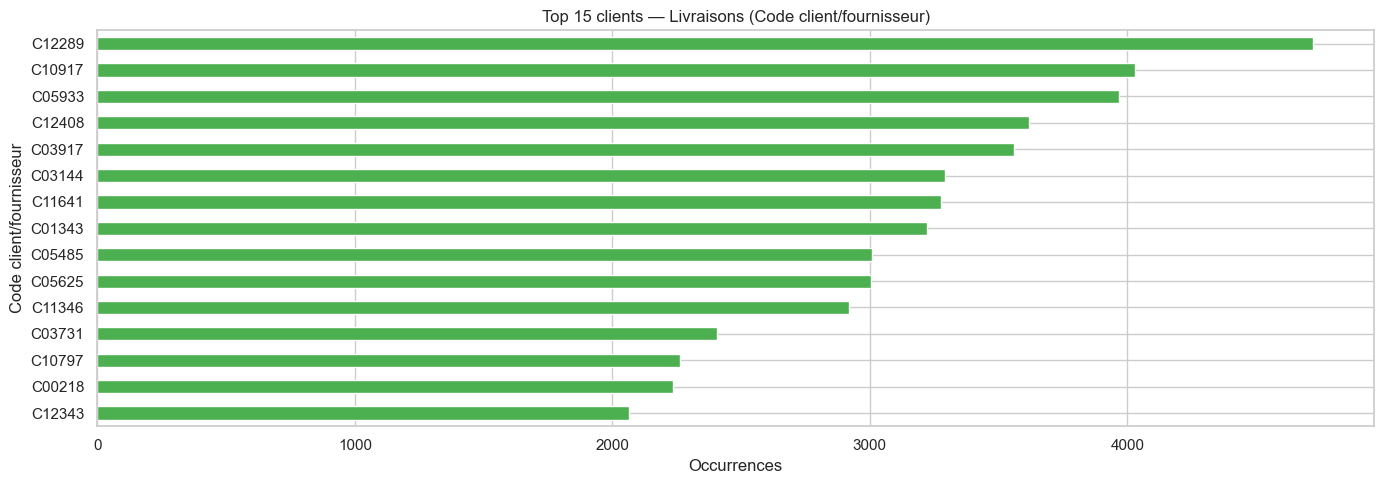

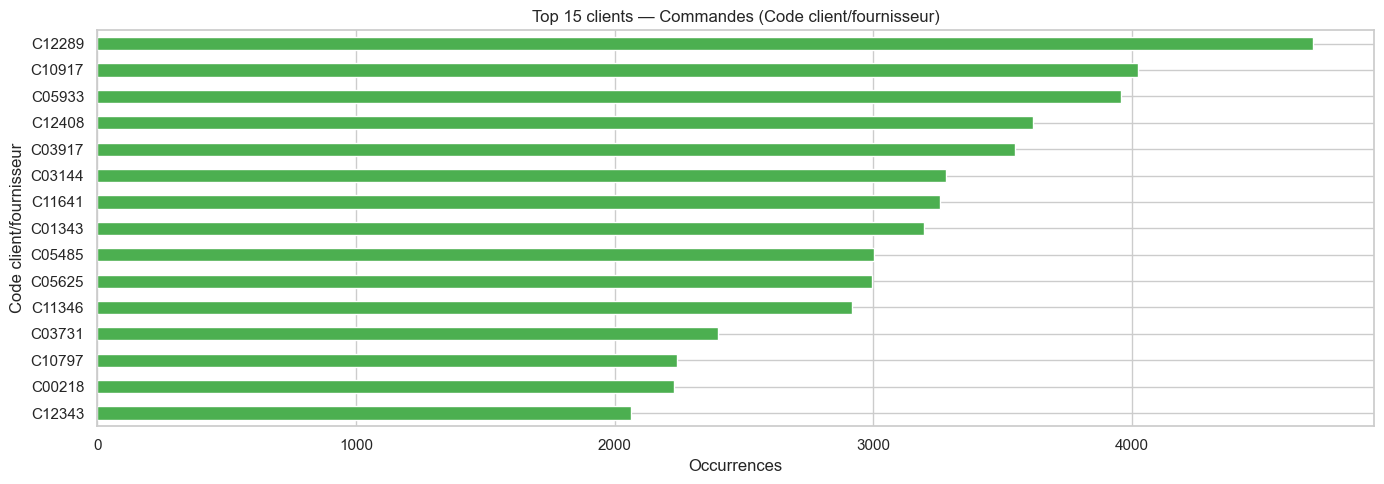

Code client/fournisseur
C12289    4702
C10917    4023
C05933    3958
C12408    3617
C03917    3549
C03144    3282
C11641    3259
C01343    3195
C05485    3002
C05625    2995
C11346    2920
C03731    2400
C10797    2240
C00218    2230
C12343    2062
Name: count, dtype: int64

In [15]:
def top_clients(df, label, top_n=15):
    client_cols = [c for c in df.columns if 'client' in c.lower() or 'nom' in c.lower()]
    if not client_cols:
        print(f'[{label}] Aucune colonne client. Colonnes: {df.columns.tolist()}')
        return
    col = client_cols[0]
    counts = df[col].value_counts().head(top_n)
    plt.figure()
    counts[::-1].plot(kind='barh', color='#4CAF50')
    plt.title(f'Top {top_n} clients — {label} ({col})')
    plt.xlabel('Occurrences')
    plt.tight_layout(); plt.show()
    return counts

top_clients(df_liv, 'Livraisons')
top_clients(df_cmd, 'Commandes')

## 7. Analyse des montants / quantites

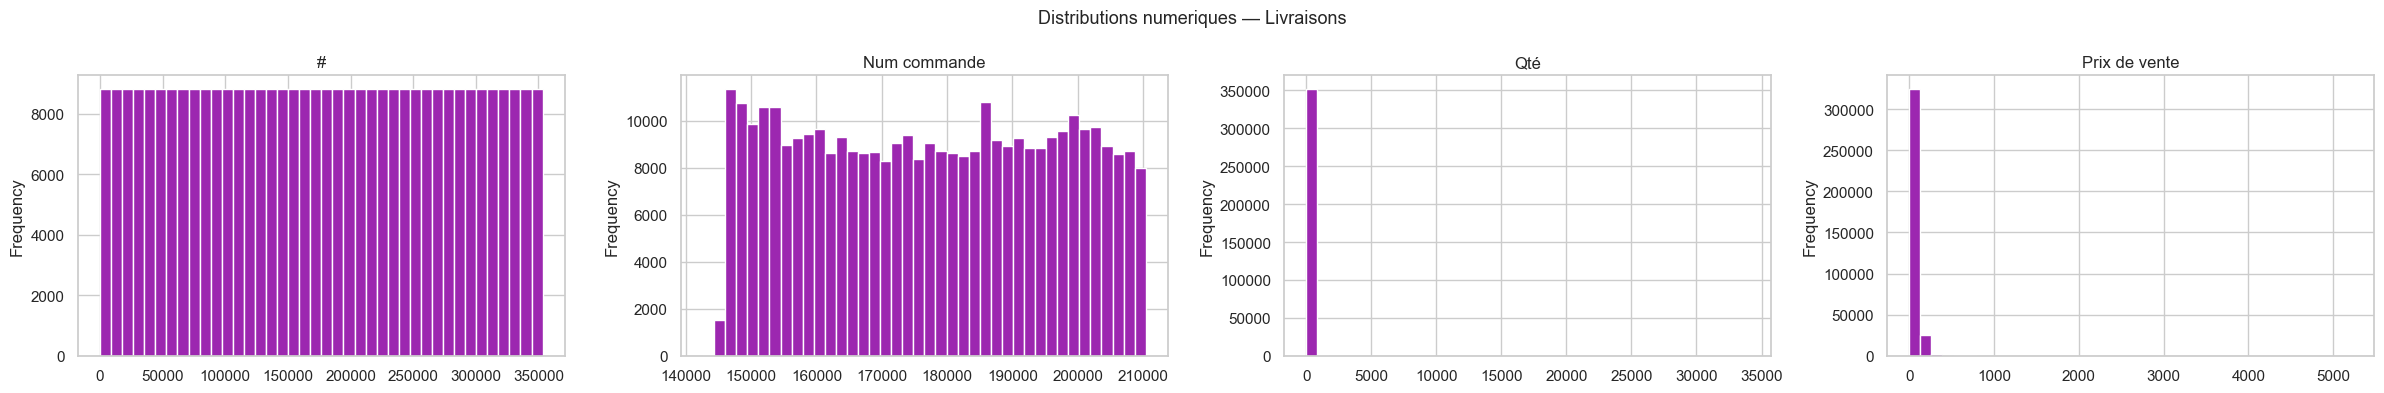

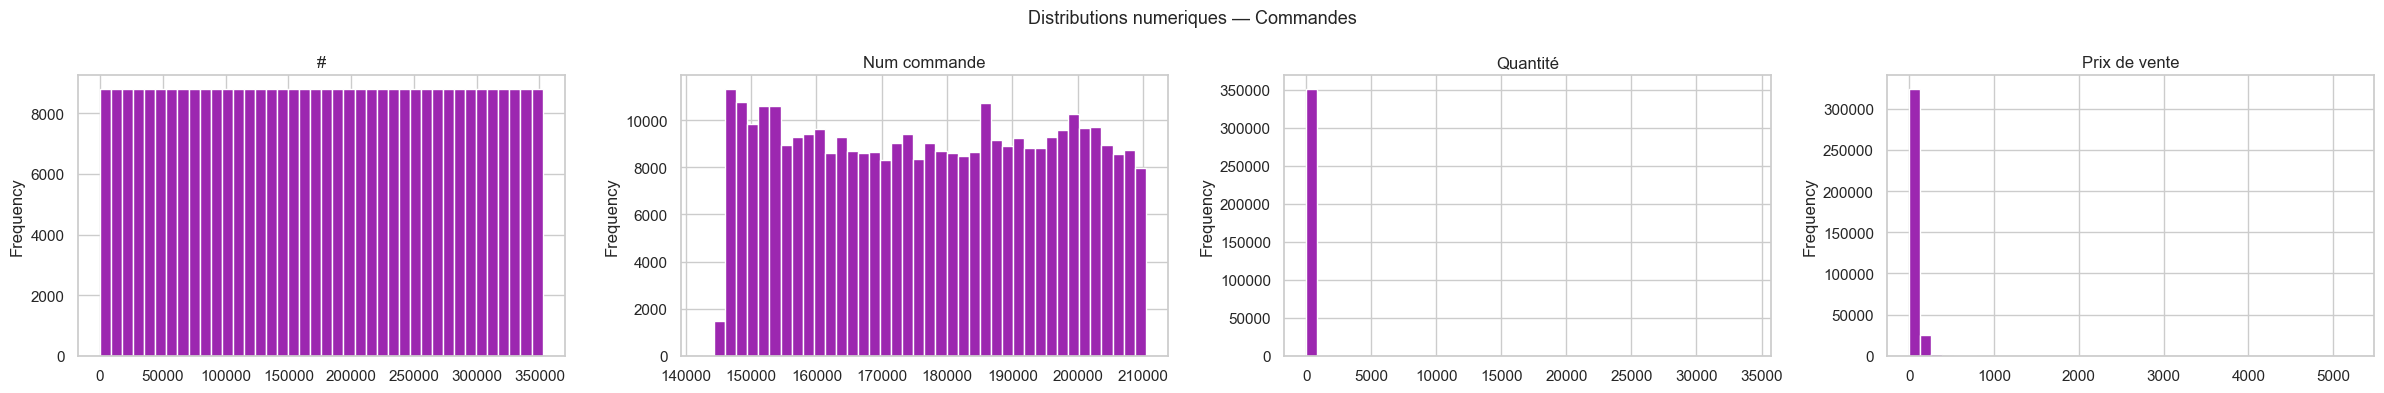

In [16]:
def plot_numeric_distributions(df, num_cols, label):
    if not num_cols:
        print(f'[{label}] Pas de colonnes numeriques.'); return
    fig, axes = plt.subplots(1, len(num_cols), figsize=(6*len(num_cols), 4))
    if len(num_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, num_cols):
        df[col].dropna().plot(kind='hist', bins=40, ax=ax, color='#9C27B0', edgecolor='white')
        ax.set_title(col)
        ax.set_xlabel('')
    fig.suptitle(f'Distributions numeriques — {label}', fontsize=13)
    plt.tight_layout(); plt.show()

plot_numeric_distributions(df_liv, num_liv, 'Livraisons')
plot_numeric_distributions(df_cmd, num_cmd, 'Commandes')

## 8. Colonnes communes entre les deux fichiers

In [17]:
common_keys = set(c.lower() for c in df_liv.columns) & set(c.lower() for c in df_cmd.columns)
print('Colonnes communes:', common_keys)
print('\nColonnes Livraisons:', df_liv.columns.tolist())
print('Colonnes Commandes :', df_cmd.columns.tolist())

Colonnes communes: {'pays/région', "numéro d'article", 'ségment stratégique', '#', 'activité stratégique client', 'prix de vente', 'num commande', 'devise du prix', 'type activité', 'code client/fournisseur', 'activité stratégique article'}

Colonnes Livraisons: ['#', 'Num commande', "Numéro d'article", 'Qté', 'Date de livraison réelle', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Prix de vente', 'Devise du prix']
Colonnes Commandes : ['#', 'Num commande', "Numéro d'article", 'Quantité', "Date d'enregistrement", 'Date de livraison demandée', 'Code client/fournisseur', 'Activité stratégique client', 'Activité stratégique article', 'Ségment stratégique', 'Type activité', 'Pays/région', 'Prix de vente', 'Devise du prix']


## 9. Taux de service (livraisons / commandes par client)

                         commandes  livraisons  taux_service_%
Code client/fournisseur                                       
C12873                        14.0         7.0            50.0
C13787                         5.0         3.0            60.0
C12762                       116.0        90.0            77.6
C13154                         5.0         4.0            80.0
C12379                        41.0        34.0            82.9
C11536                        19.0        16.0            84.2
C13398                        14.0        12.0            85.7
C13070                         7.0         6.0            85.7
C00720                         8.0         7.0            87.5
C11418                        27.0        24.0            88.9
C12248                         9.0         8.0            88.9
C03330                        39.0        35.0            89.7
C01061                        10.0         9.0            90.0
C13212                        11.0        10.0         

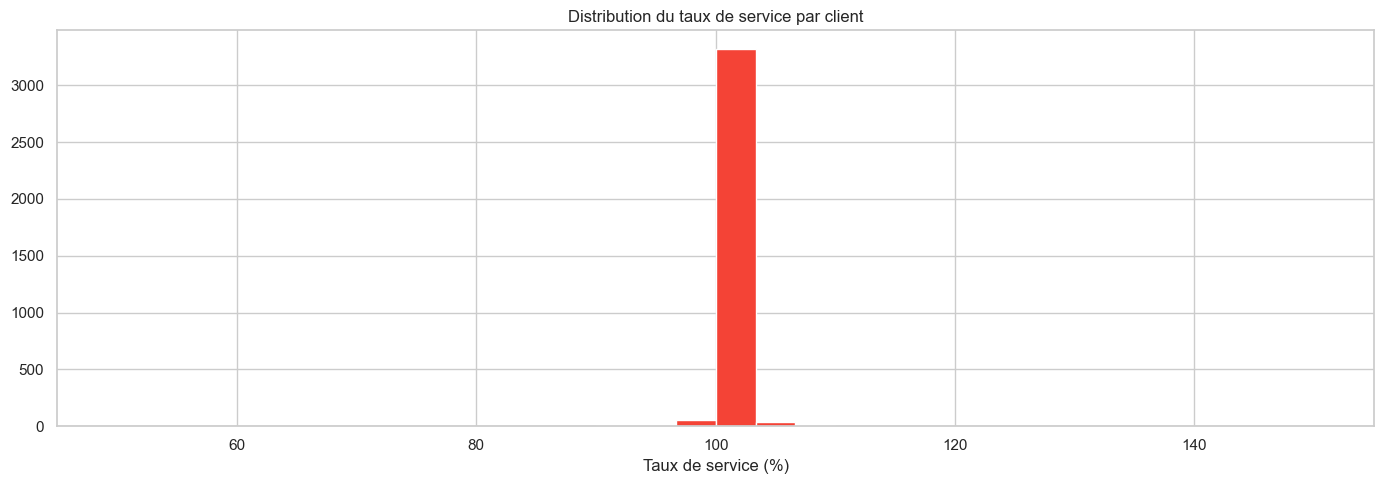

In [18]:
client_liv = [c for c in df_liv.columns if 'client' in c.lower()]
client_cmd = [c for c in df_cmd.columns if 'client' in c.lower()]

if client_liv and client_cmd:
    vol_liv = df_liv[client_liv[0]].value_counts().rename('livraisons')
    vol_cmd = df_cmd[client_cmd[0]].value_counts().rename('commandes')
    taux = pd.concat([vol_cmd, vol_liv], axis=1).dropna()
    taux['taux_service_%'] = (taux['livraisons'] / taux['commandes'] * 100).round(1)
    taux = taux.sort_values('taux_service_%')
    print(taux.head(20))
    taux['taux_service_%'].hist(bins=30, color='#F44336', edgecolor='white')
    plt.title('Distribution du taux de service par client')
    plt.xlabel('Taux de service (%)')
    plt.tight_layout(); plt.show()
else:
    print('Colonne client non trouvee. Verifier les noms de colonnes en cellule 8.')

## 10. Resume statistique final

In [19]:
print('=== RESUME ===')
print(f'Livraisons : {len(df_liv):,} lignes | {df_liv.shape[1]} colonnes')
print(f'Commandes  : {len(df_cmd):,} lignes | {df_cmd.shape[1]} colonnes')

for df, label in [(df_liv, 'Livraisons'), (df_cmd, 'Commandes')]:
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    for col in date_cols:
        print(f'[{label}] {col} : {df[col].min()} -> {df[col].max()}')

=== RESUME ===
Livraisons : 353,325 lignes | 13 colonnes
Commandes  : 352,549 lignes | 14 colonnes
[Livraisons] Date de livraison réelle : 2021-01-04 00:00:00 -> 2025-12-23 00:00:00
[Commandes] Date d'enregistrement : 2020-09-23 00:00:00 -> 2025-12-23 00:00:00
[Commandes] Date de livraison demandée : 2021-01-04 00:00:00 -> 2025-12-23 00:00:00
